*file import
*nulls
*.shape
*info
*describe 
*distribution plot
*box plot 
*visualization - biverat multiverate
*encoder categorical to numerical
*heat map
*standard scaler
*train test
linear regression 
r2 score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import Series, DataFrame

In [9]:
train = pd.read_csv("D:\\Project\\DA\\Retail_Sales\\train.csv.xls", parse_dates=["Date"])
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [11]:
features = pd.read_csv("D:\\Project\\DA\\Retail_Sales\\features.csv.xls", parse_dates=["Date"])
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [13]:
stores = pd.read_csv("D:\\Project\\DA\\Retail_Sales\\stores.csv.xls")
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [15]:
merged=pd.merge(train,features,on=['Store','Date']);
merged.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [17]:
merged_2=pd.merge(merged,stores,on='Store')
merged_2.head(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [19]:
merged_2.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [21]:
merged_2['MarkDown1'].fillna(merged_2['MarkDown1'].mean(),inplace=True)
merged_2['MarkDown2'].fillna(merged_2['MarkDown2'].mean(),inplace=True)
merged_2['MarkDown3'].fillna(merged_2['MarkDown3'].mean(),inplace=True)
merged_2['MarkDown4'].fillna(merged_2['MarkDown4'].mean(),inplace=True)
merged_2['MarkDown5'].fillna(merged_2['MarkDown5'].mean(),inplace=True)

C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\1396803929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_2['MarkDown1'].fillna(merged_2['MarkDown1'].mean(),inplace=True)
C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\1396803929.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [23]:
merged_2.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
Type            0
Size            0
dtype: int64

In [25]:
merged_2

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.610000,20.640000,1.500000,1601.010000,3288.250000,192.013558,8.684,False,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.740000,3334.628621,18.820000,2253.430000,2340.010000,192.170412,8.667,False,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.280000,3334.628621,7.890000,599.320000,3990.540000,192.327265,8.667,False,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.020000,3334.628621,3.180000,437.730000,1537.490000,192.330854,8.667,False,B,118221


In [27]:
merged_2.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,7246.420196,3334.628621,115.390000,3383.168256,4628.975079,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,4956.920816,4867.493911,5487.601593,3560.353127,3573.795304,39.159276,1.863296,60980.583328


In [29]:
merged_2.shape

(421570, 17)

In [31]:
merged_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

<Axes: xlabel='Weekly_Sales', ylabel='Count'>

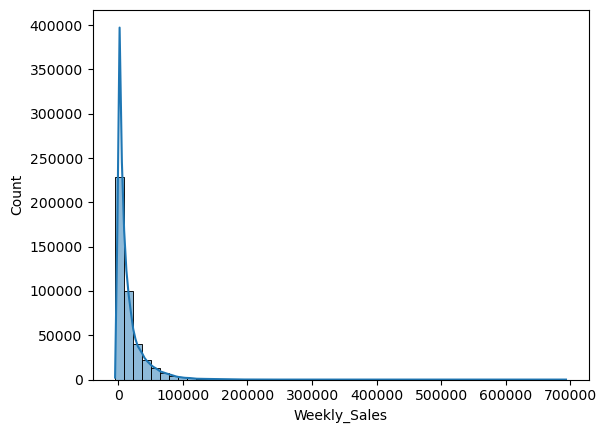

In [33]:
sns.histplot(merged_2['Weekly_Sales'], bins=50, kde=True)


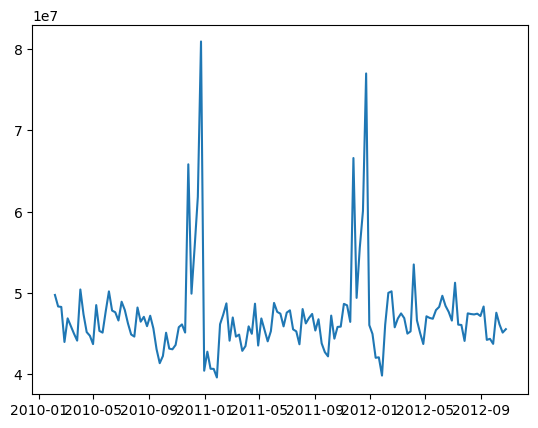

In [36]:
sales_by_date = merged_2.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.plot(sales_by_date['Date'], sales_by_date['Weekly_Sales'])

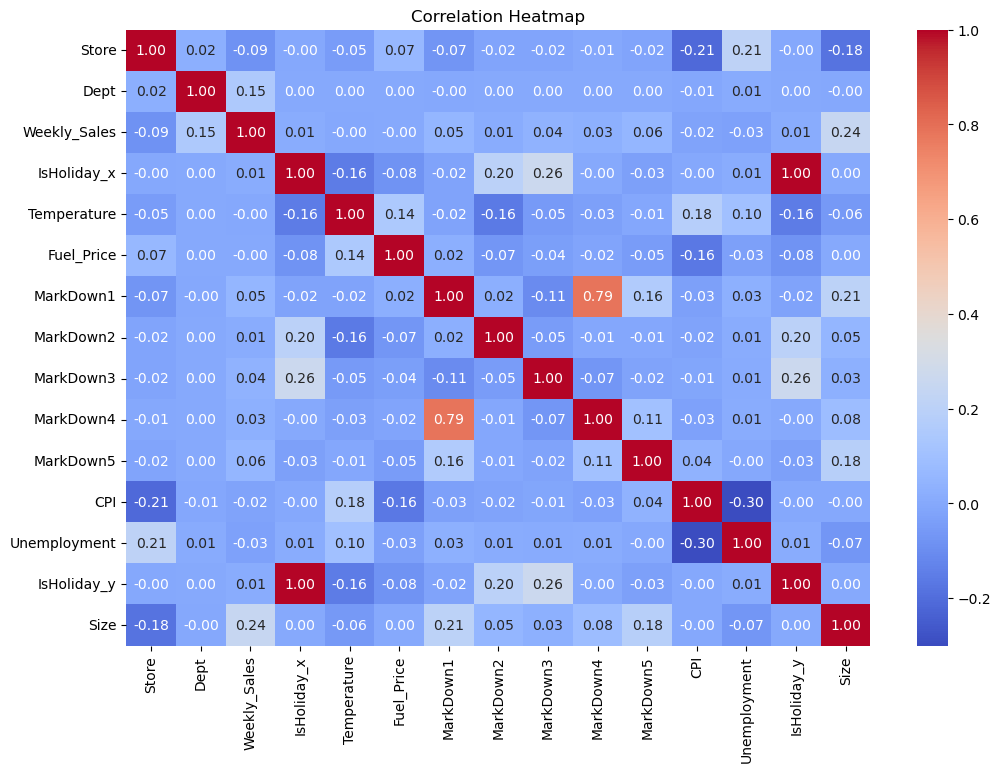

In [38]:
plt.figure(figsize=(12,8))
corr = merged_2.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

<Axes: xlabel='Unemployment', ylabel='Weekly_Sales'>

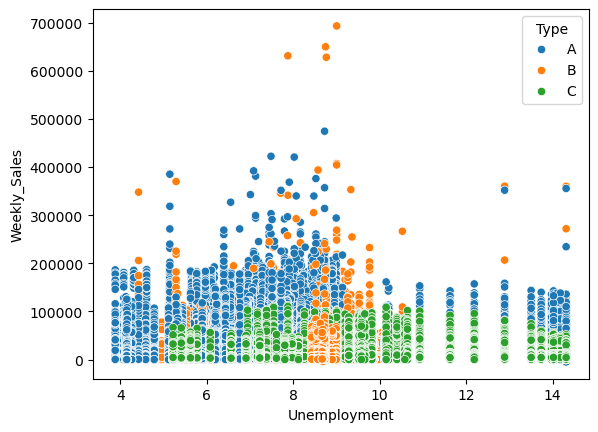

In [40]:
sns.scatterplot(data=merged_2, x='Unemployment', y='Weekly_Sales', hue='Type')

(array([1.03043e+05, 1.25197e+05, 6.22980e+04, 3.81420e+04, 2.30550e+04,
        1.68590e+04, 1.24190e+04, 9.42500e+03, 7.19200e+03, 5.49400e+03,
        4.17000e+03, 3.38900e+03, 2.58300e+03, 1.74900e+03, 1.37300e+03,
        9.92000e+02, 8.79000e+02, 6.17000e+02, 4.31000e+02, 3.87000e+02,
        3.45000e+02, 3.22000e+02, 2.91000e+02, 2.21000e+02, 1.77000e+02,
        1.32000e+02, 1.06000e+02, 6.10000e+01, 4.50000e+01, 2.70000e+01,
        3.30000e+01, 1.00000e+01, 1.90000e+01, 6.00000e+00, 8.00000e+00,
        1.00000e+01, 1.00000e+00, 6.00000e+00, 7.00000e+00, 5.00000e+00,
        1.00000e+00, 1.00000e+00, 5.00000e+00, 3.00000e+00, 2.00000e+00,
        1.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00, 4.00000e+00,
        2.00000e+00, 5.00000e+00, 2.00000e+00, 2.00000e+00, 1.00000e+00,
        2.00000e+00, 1.00000e+00, 1.00000e+00, 1.00000e+00, 1.00000e+00,
        1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00

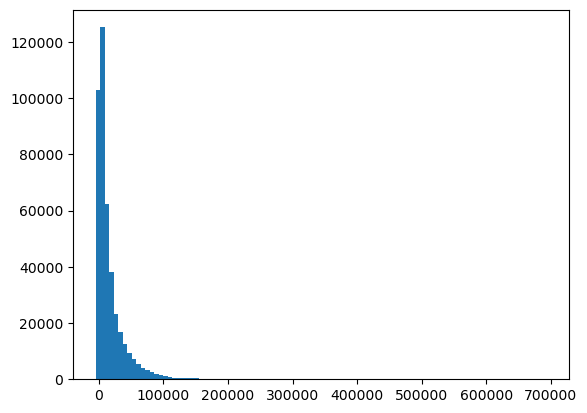

In [42]:
plt.hist(merged_2['Weekly_Sales'],bins=100)

C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\522141520.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_2['Weekly_Sales'])


<Axes: xlabel='Weekly_Sales', ylabel='Density'>

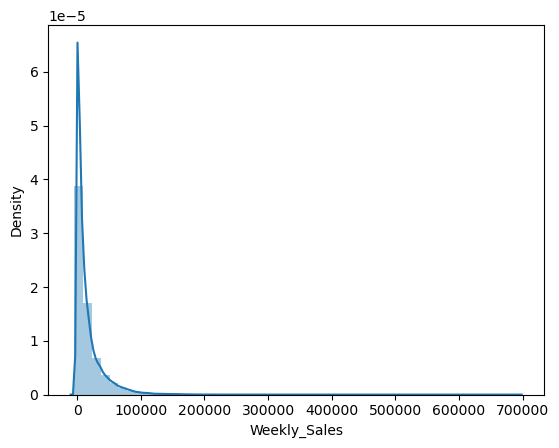

In [44]:
sns.distplot(merged_2['Weekly_Sales'])

<Axes: ylabel='Fuel_Price'>

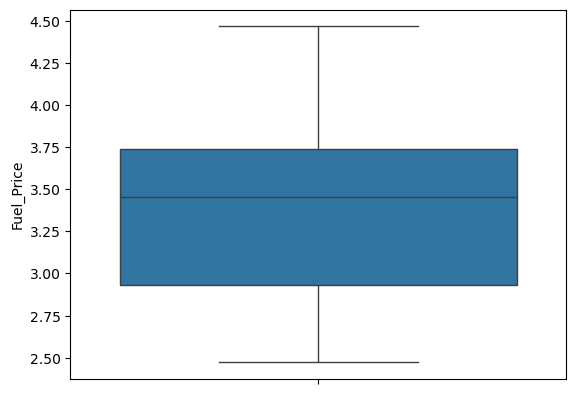

In [45]:
sns.boxplot(merged_2['Fuel_Price'])

<Axes: ylabel='Unemployment'>

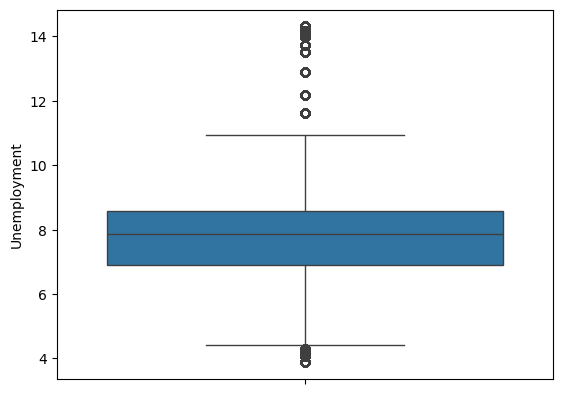

In [46]:
sns.boxplot(merged_2['Unemployment'])

In [50]:
percentile25 = merged_2['Unemployment'].quantile(0.25)
percentile25

6.891

In [52]:
percentile75 = merged_2['Unemployment'].quantile(0.75)
percentile75

8.572

In [ ]:
iqr = percentile75 - percentile25
iqr

1.6809999999999992

In [56]:
upper_limit = percentile75 + 1.5* iqr
lower_limit = percentile25 +1.5*iqr

In [58]:
upper_limit

11.093499999999999

In [60]:
lower_limit

9.412499999999998

In [62]:
merged_2[merged_2['Unemployment']> upper_limit]

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
107901,12,1,2010-02-05,17426.75,False,49.47,2.962,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.442065,13.975,False,B,112238
107902,12,1,2010-02-12,37734.82,True,47.87,2.946,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.496258,13.975,True,B,112238
107903,12,1,2010-02-19,22135.29,False,54.83,2.915,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.526286,13.975,False,B,112238
107904,12,1,2010-02-26,14942.21,False,50.23,2.825,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.552286,13.975,False,B,112238
107905,12,1,2010-03-05,17098.49,False,53.77,2.987,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.578286,13.975,False,B,112238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361055,38,98,2012-06-08,4799.44,False,84.83,4.103,491.310000,3334.628621,11.800000,3383.168256,1999.190000,130.889677,11.627,False,C,39690
361056,38,98,2012-06-15,4239.92,False,85.94,4.144,635.420000,3334.628621,0.130000,3383.168256,1800.180000,130.829533,11.627,False,C,39690
361057,38,98,2012-06-22,4000.23,False,91.61,4.014,576.000000,3334.628621,1439.421384,3383.168256,2241.950000,130.792900,11.627,False,C,39690
361058,38,98,2012-06-29,4005.14,False,90.47,3.875,350.560000,3334.628621,1439.421384,26.870000,1447.290000,130.756267,11.627,False,C,39690


In [64]:
merged_2[merged_2['Unemployment']> lower_limit]

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
87524,10,1,2010-02-05,40212.84,False,54.34,2.962,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.442065,9.765,False,B,126512
87525,10,1,2010-02-12,67699.32,True,49.96,2.828,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.496258,9.765,True,B,126512
87526,10,1,2010-02-19,49748.33,False,58.22,2.915,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.526286,9.765,False,B,126512
87527,10,1,2010-02-26,33601.22,False,52.77,2.825,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.552286,9.765,False,B,126512
87528,10,1,2010-03-05,36572.44,False,55.92,2.877,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,126.578286,9.765,False,B,126512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404742,43,98,2012-06-29,7016.75,False,89.85,3.286,289.030000,3334.628621,1439.421384,3383.168256,2027.070000,213.246062,9.575,False,C,41062
404760,43,99,2011-05-06,25.00,False,66.77,3.906,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,207.571493,10.581,False,C,41062
404761,43,99,2011-11-18,50.00,False,57.75,3.308,32.130000,3.370000,2.560000,3383.168256,1004.040000,209.865107,10.148,False,C,41062
404762,43,99,2012-01-06,25.00,False,47.59,3.157,32.950000,1699.030000,70.350000,3383.168256,1168.660000,211.242813,9.653,False,C,41062


In [66]:
trimmed = merged_2[merged_2['Unemployment']> upper_limit]
trimmed.shape

(23917, 17)

C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\307151295.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_2['Unemployment'])
C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\307151295.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(trimmed['Unemployment'])


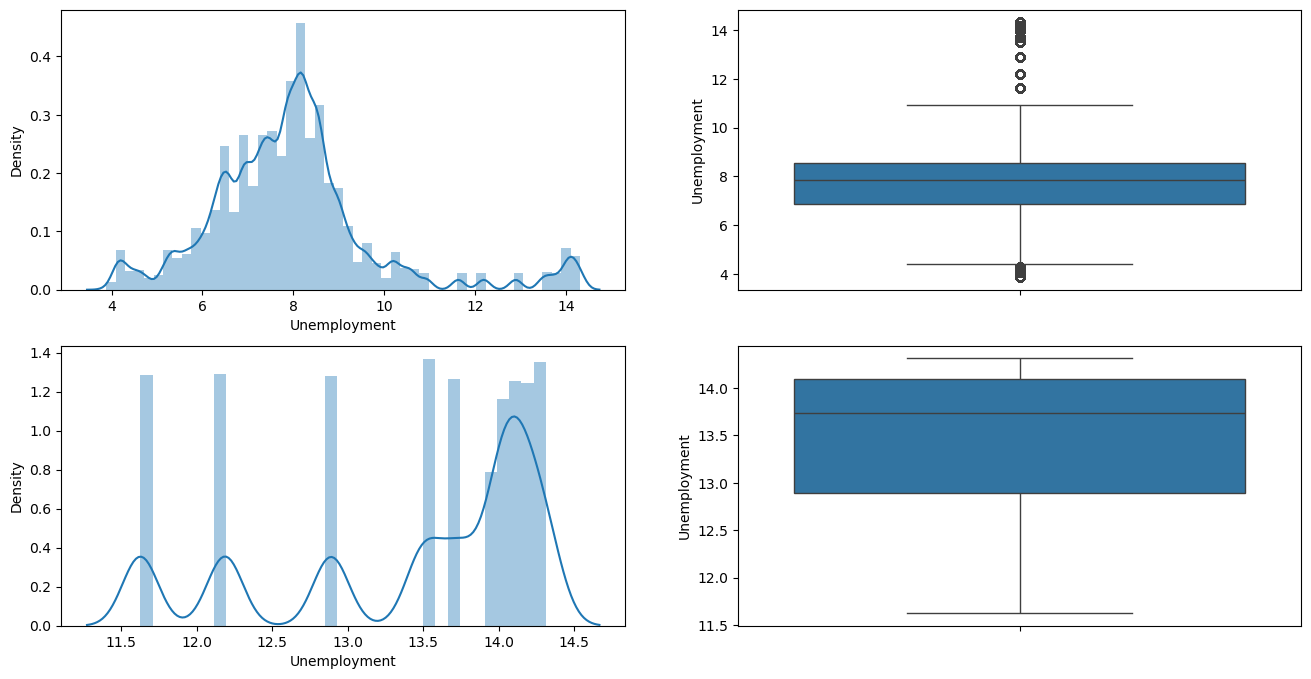

In [68]:
plt.figure(figsize =(16,8))
plt.subplot(2,2,1)
sns.distplot(merged_2['Unemployment'])


plt.subplot(2,2,2)
sns.boxplot(merged_2['Unemployment'])

plt.subplot(2,2,3)
sns.distplot(trimmed['Unemployment'])

plt.subplot(2,2,4)
sns.boxplot(trimmed['Unemployment'])

plt.show()

In [70]:
pd.crosstab(merged_2['Store'],merged_2['Type'])

Type,A,B,C
Store,,,
1,10244,0,0
2,10238,0,0
3,0,9036,0
4,10272,0,0
5,0,8999,0
6,10211,0,0
7,0,9762,0
8,9895,0,0
9,0,8867,0


<Axes: xlabel='col_0', ylabel='Store'>

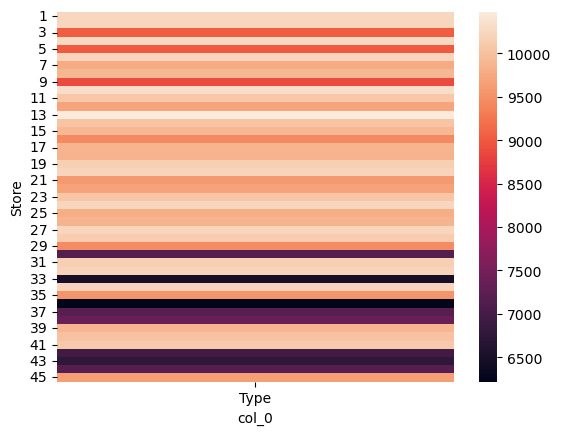

In [72]:
sns.heatmap(pd.crosstab(merged_2['Store'],['Type']))

In [74]:
#6.	Data Transformation 
 	# Log transformation (only if all values are > 0)
merged_2['CPI_log'] = np.log(merged_2['CPI'])

In [76]:
from sklearn.preprocessing import PowerTransformer

# Box-Cox requires all positive values
pt_boxcox = PowerTransformer(method='box-cox')
merged_2['CPI_boxcox'] = pt_boxcox.fit_transform(merged_2[['CPI']])

In [77]:
pt_yeo = PowerTransformer(method='yeo-johnson')
merged_2['CPI_yeojohnson'] = pt_yeo.fit_transform(merged_2[['CPI']])

C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\3890194720.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_2['CPI_boxcox'], color='blue', label='Boxcox Transformed', kde=True)
C:\Users\mg570\AppData\Local\Temp\ipykernel_1920\3890194720.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dis

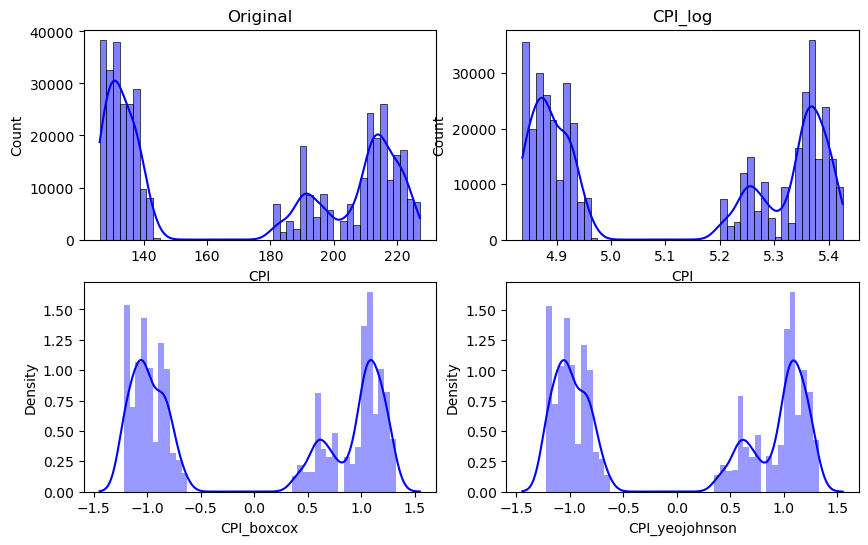

In [80]:
# original
plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
plt.title('Original')
sns.histplot(merged_2['CPI'], color='blue', label='Original', kde=True)
plt.xlabel('CPI')


plt.subplot(2,2,2)
plt.title('CPI_log')
sns.histplot(merged_2['CPI_log'], color='blue', label='Log Transformed', kde=True)
plt.xlabel('CPI')


plt.subplot(2,2,3)
sns.distplot(merged_2['CPI_boxcox'], color='blue', label='Boxcox Transformed', kde=True)

plt.subplot(2,2,4)
sns.distplot(merged_2['CPI_yeojohnson'] , color='blue', label='yeojohnson Transformed', kde=True)

plt.show()


In [83]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

NameError: name 'df' is not defined

In [ ]:
merged_2['Date'] = pd.to_datetime(merged_2['Date'])

In [ ]:
merged_2['Year'] = merged_2['Date'].dt.year
merged_2['Month'] = merged_2['Date'].dt.month
merged_2['Week'] = merged_2['Date'].dt.isocalendar().week
merged_2['Day'] = merged_2['Date'].dt.day

In [ ]:
print(merged_2.columns)


In [ ]:
merged_2['IsHoliday'] = merged_2['IsHoliday'].astype(int)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
merged_2['Type'] = le.fit_transform(merged_2['Type'])
merged_2

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
merged_3 = merged_2.copy()

In [ ]:
features = merged_3.drop(['Weekly_Sales', 'Date'], axis=1)


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df['Weekly_Sales'] = merged_3['Weekly_Sales'].values
scaled_df.head()

In [ ]:
from sklearn.model_selection import train_test_split

In [94]:
X = scaled_df.drop('Weekly_Sales', axis=1)
y = scaled_df['Weekly_Sales']

NameError: name 'scaled_df' is not defined

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

NameError: name 'train_test_split' is not defined

In [98]:
from sklearn.linear_model import LinearRegression

In [154]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [174]:
y_pred = lr.predict(X_test)

In [176]:
from sklearn.metrics import r2_score


In [180]:
r2_score(y_test, y_pred)


0.08975120448100937

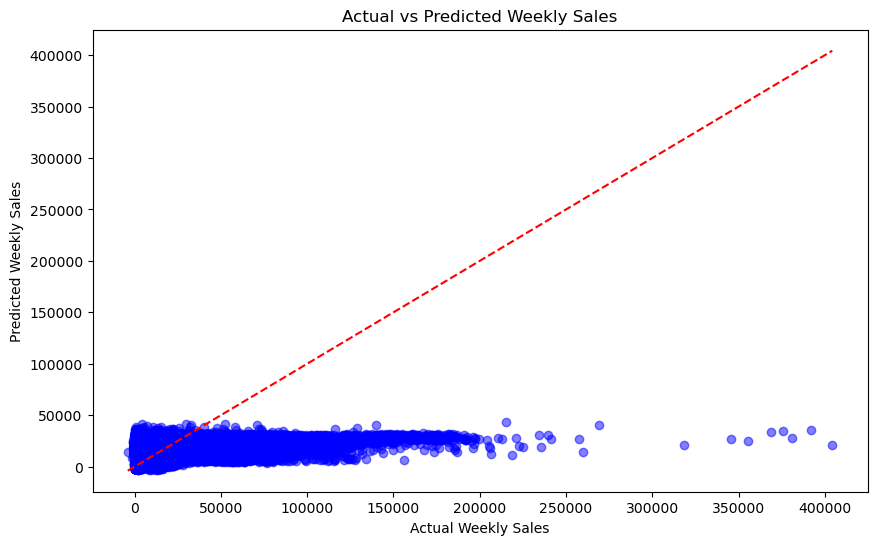

In [182]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Actual vs Predicted Weekly Sales')
plt.show()